In [1]:
#import msg
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
#llm model
from langchain_google_genai import ChatGoogleGenerativeAI
#load env variable
from dotenv import load_dotenv
#toolnode
from langgraph.prebuilt import ToolNode
#create tool
from langchain_core.tools import tool
#state structure
from typing import TypedDict, Literal
#
from typing_extensions import Annotated
#reducer
from langgraph.graph.message import add_messages
#graph building
from langgraph.graph import StateGraph, START, END
#os module
import os

load_dotenv()
project = os.getenv('GOOGLE_CLOUD_PROJECT')

# model
llm = ChatGoogleGenerativeAI(
    model = "gemini-2.5-flash-lite",
    vertexai = True,
    project = project
)

In [2]:
#It stores conversation
from langgraph.graph import MessagesState

In [3]:
#create nodes   #node 1 (Expert)
def node_1(state:MessagesState):
#Giving system instruction
    role=[SystemMessage(content="you are expert in the filed of software")]
    response=llm.invoke(role + state["messages"])
    return {"messages": [response]}

In [6]:
#node 2 (Assistant)
def node_2(state:MessagesState):
    role = [SystemMessage(content="You are helpful assistant")]
    response = llm.invoke(role + state["messages"])
    return {"messages": [response]}


In [7]:
#Create Graph   (created workflow graph)
graph=StateGraph(MessagesState)


In [8]:
#Add Nodes
graph.add_node("expert",node_1)
graph.add_node("Assistant",node_2)


In [9]:
#Define Flow (sequence)
graph.set_entry_point("expert")
graph.add_edge("expert","Assistant")
graph.set_finish_point("Assistant")

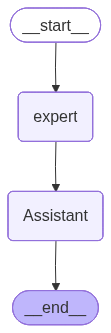

In [10]:
#Compile Graph
state_graph=graph.compile()
state_graph

In [11]:
#run graph
response = state_graph.invoke(
    {"messages": [HumanMessage(content="What is class ?")]})

In [12]:
# Print Output
for message in response['messages']:
    print(message.content)

What is class ?
In the realm of software development, particularly within **object-oriented programming (OOP)**, a **class** is a fundamental concept. Think of it as a **blueprint** or a **template** for creating objects. It defines the structure and behavior that objects of that type will have.

Here's a breakdown of what a class is and its key components:

**Analogy:**

Imagine you want to build several houses.

*   **Class:** The **architectural blueprint** for a specific type of house (e.g., a "Two-Story Colonial"). This blueprint details how many rooms it will have, where the windows and doors go, what materials to use, etc.
*   **Object:** An **actual house** built according to that blueprint. Each house will be a distinct instance, even though they share the same fundamental structure and features defined by the blueprint.

**Key Components of a Class:**

1.  **Attributes (or Properties, Fields, Data Members):**
    *   These define the **state** or the **data** that an object o

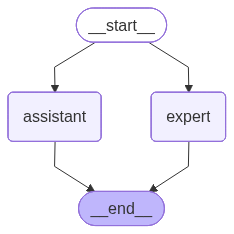

In [13]:
graph = StateGraph(MessagesState)

graph.add_node("expert", node_1)
graph.add_node("assistant", node_2)
graph.set_entry_point("expert")
graph.set_entry_point("assistant")
graph.set_finish_point("assistant")
graph.set_finish_point("expert")
state_graph = graph.compile()
state_graph

In [14]:
response=state_graph.invoke({
    "messages":[HumanMessage(content="what is a class")]
})
   

In [15]:
for message in response['messages']:
    print(message.content)

what is a class
In object-oriented programming (OOP), a **class** is a blueprint or a template for creating objects. Think of it as a cookie cutter: the cookie cutter itself isn't a cookie, but it defines the shape and characteristics of all the cookies you can make with it.

Here's a breakdown of what a class represents and its key components:

**1. Blueprint for Objects:**

*   A class defines the **properties (attributes or data)** that an object will have and the **behaviors (methods or functions)** that an object can perform.
*   When you create an instance of a class, you get an **object**. Each object created from the same class will have the same set of properties and behaviors, but their specific values for those properties can be different.

**2. Key Components of a Class:**

*   **Attributes (Properties/Data Members):** These are variables that store the state or characteristics of an object. They define *what* an object is.
    *   **Example:** If you have a `Car` class, at

In [ ]:
# Both codes give similar answers,
#  but in the first both nodes run,
#  while in the second only one node runs due to overwritten entry/finish and no edges.

In [ ]:
# Sample Structure used (creating a custom state)

class ExtendedMessagesState(MessagesState):
    expert_one: str = "Software"
    expert_two: str = "Design"

In [ ]:
def ask_question(state: MessagesState):
    response = llm.invoke(state["messages"])
    return {"messages": response}
#It returns new message  LangGraph automatically: adds it to state


In [ ]:
#Create Graph
chat_graph = StateGraph(MessagesState)
chat_graph.add_node("chat", ask_question)
chat_graph.set_entry_point("chat")
chat_graph.set_finish_point("chat")
#Compile Graph
chat_state_graph = chat_graph.compile()



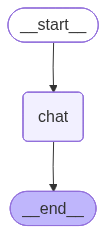

In [19]:
chat_state_graph

In [20]:
# in my state i have list of lenght 1
response = chat_state_graph.invoke({
    "messages": [HumanMessage("What is captial of france?")]
})

len(response['messages'])

2

In [21]:
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

The capital of France is **Paris**.


In [22]:
response = state_graph.invoke(
    {"messages": [HumanMessage(content="What are good spots in the city")]}
)
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

To give you the best recommendations, I need a little more information! "The city" is a bit vague.

**Please tell me:**

1.  **Which city are you interested in?** (e.g., New York City, London, Tokyo, Paris, your local city, etc.)

Once I know the city, I can give you much more specific and helpful suggestions.

**In the meantime, to help you think about what you're looking for, consider these general categories of "good spots":**

*   **For Foodies:**
    *   Michelin-starred restaurants
    *   Local hidden gems and street food
    *   Specific cuisines (Italian, Thai, Mexican, etc.)
    *   Bakeries, cafes, or dessert shops
    *   Farmers' markets

*   **For Culture & Arts:**
    *   Museums (art, history, science)
    *   Galleries
    *   Theaters (plays, musicals, opera)
    *   Live music venues
    *   Historical landmarks and architecture

*   **For Relaxation & Nature:**
    *   Parks and garden

In [23]:
config = {"configurable": {"thread_id": "3"}}

response = chat_state_graph.invoke({
    "messages": [HumanMessage("What is captial of france?")]
}, config=config
)
len(response['messages'])

2

In [24]:
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

The capital of France is **Paris**.


In [25]:
response = chat_state_graph.invoke(
    {
        "messages": [HumanMessage(content="What are good spots in this city")]
    },
    config=config
)
len(response['messages'])

response['messages']

[HumanMessage(content='What are good spots in this city', additional_kwargs={}, response_metadata={}, id='5890eba0-e96c-4769-80be-3a29cf889a90'),
 AIMessage(content='To give you the **best recommendations**, I need a little more information! Please tell me:\n\n**1. Which city are you asking about?**\n\nOnce you tell me the city, I can help you with:\n\n**General Categories of "Good Spots":**\n\n*   **For Tourists:** Iconic landmarks, historical sites, popular attractions.\n*   **For Foodies:** Highly-rated restaurants, local specialties, unique dining experiences, food markets.\n*   **For Nature Lovers:** Parks, hiking trails, scenic viewpoints, gardens, waterfronts.\n*   **For Art & Culture Enthusiasts:** Museums, galleries, theaters, live music venues, historical districts.\n*   **For Nightlife:** Bars, clubs, breweries, live music spots, late-night eateries.\n*   **For Families:** Kid-friendly attractions, parks, interactive museums, playgrounds.\n*   **For Relaxation & Wellness:** 

In [26]:
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

To give you the **best recommendations**, I need a little more information! Please tell me:

**1. Which city are you asking about?**

Once you tell me the city, I can help you with:

**General Categories of "Good Spots":**

*   **For Tourists:** Iconic landmarks, historical sites, popular attractions.
*   **For Foodies:** Highly-rated restaurants, local specialties, unique dining experiences, food markets.
*   **For Nature Lovers:** Parks, hiking trails, scenic viewpoints, gardens, waterfronts.
*   **For Art & Culture Enthusiasts:** Museums, galleries, theaters, live music venues, historical districts.
*   **For Nightlife:** Bars, clubs, breweries, live music spots, late-night eateries.
*   **For Families:** Kid-friendly attractions, parks, interactive museums, playgrounds.
*   **For Relaxation & Wellness:** Spas, quiet cafes, serene spots, yoga studios.
*   **For Shopping:** Boutiques, local markets, uni

In [27]:
def response_from_llm(state: MessagesState):
    return {
        "messages": llm.invoke(state["messages"])
    }

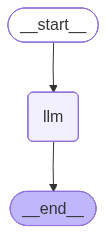

In [28]:
state_learning_graph = StateGraph(MessagesState)
state_learning_graph.add_node("llm", response_from_llm)

state_learning_graph.set_entry_point("llm")
state_learning_graph.set_finish_point("llm")

compiled_state_learning_graph = state_learning_graph.compile()
compiled_state_learning_graph

In [29]:
config = {"configurable": {"thread_id": "1"}}

input_message = HumanMessage(content="Hi this is Ram speaking")
output = compiled_state_learning_graph.invoke(
    {
        "messages": [input_message]
    }, 
    config
)
output['messages'][-1].pretty_print()

================================== Ai Message ==================================

Hi Ram, it's nice to hear from you! How can I help you today?


In [30]:
previous_message = output['messages']
previous_message

[HumanMessage(content='Hi this is Ram speaking', additional_kwargs={}, response_metadata={}, id='3fbc3496-a722-4ca0-929d-d575226c2d02'),
 AIMessage(content="Hi Ram, it's nice to hear from you! How can I help you today?", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d8c3b-7c35-7343-a3f0-5a5bb6356cfa-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 5, 'output_tokens': 19, 'total_tokens': 24, 'input_token_details': {'cache_read': 0}})]

In [31]:
input_message = HumanMessage(content="What is my name ?")
output = compiled_state_learning_graph.invoke(
    {
        # There is a native way of doing this  => checkpoint, memory and thread
        "messages": previous_message + [input_message]
    }, 
    config
)
output['messages'][-1].pretty_print()

================================== Ai Message ==================================

You just told me your name is Ram. 😊
